In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_2d_bat_flight

from grid_cells.attractor_networks import ToroidZhang1996

import tqdm
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

In [2]:
T = 200
dt = 0.5e-3
n = 64

net = ToroidZhang1996(n=n, dt=dt, periodicity=13, revolutions=1)
net.warm_up()

Ran warm up for 2408 steps


In [3]:
bat_flight = generate_2d_bat_flight(T=T, dt=dt, speed_correlation_time=5)
recorded_cells = list(np.random.randint(0, n - 1, size=(9, 2)))
n_recorded_cells = len(recorded_cells)

n_steps = bat_flight["time"].shape[0]
n_popul_snapshots = 1000
recording = np.zeros((n_steps, len(recorded_cells)))
population_recordings = np.zeros((n_popul_snapshots, n, n))
popul_snapshots_integers = np.linspace(0, n_steps, n_popul_snapshots - 1, dtype=int)
snapshot_iter = 0
for step_iter in tqdm.tqdm(range(n_steps)):
    recording[step_iter] = np.array(
        [net.s[*cell_index] for cell_index in recorded_cells]
    )
    net.step(*bat_flight["dir_vel"][step_iter])
    if step_iter == popul_snapshots_integers[snapshot_iter]:
        population_recordings[snapshot_iter] = net.s
        snapshot_iter += 1

os.makedirs(DATA_DIR, exist_ok=True)
np.save(os.path.join(DATA_DIR, "bat_2d_cell_recording.npy"), recording)
np.save(os.path.join(DATA_DIR, "bat_2d_cell_population.npy"), population_recordings)
np.save(os.path.join(DATA_DIR, "bat_2d_cell_position.npy"), bat_flight["pos"])
np.save(os.path.join(DATA_DIR, "bat_2d_cell_velocity.npy"), bat_flight["vel"])
np.save(os.path.join(DATA_DIR, "bat_2d_cell_direction.npy"), bat_flight["dir_torus"])
np.save(
    os.path.join(DATA_DIR, "bat_2d_cell_direction_sphere.npy"), bat_flight["dir_sphere"]
)

np.save(
    os.path.join(DATA_DIR, "bat_2d_cell_turn_velocity.npy"),
    bat_flight["dir_vel"],
)
np.save(os.path.join(DATA_DIR, "bat_2d_cell_time.npy"), bat_flight["time"])

100%|██████████| 400000/400000 [01:40<00:00, 3979.39it/s]


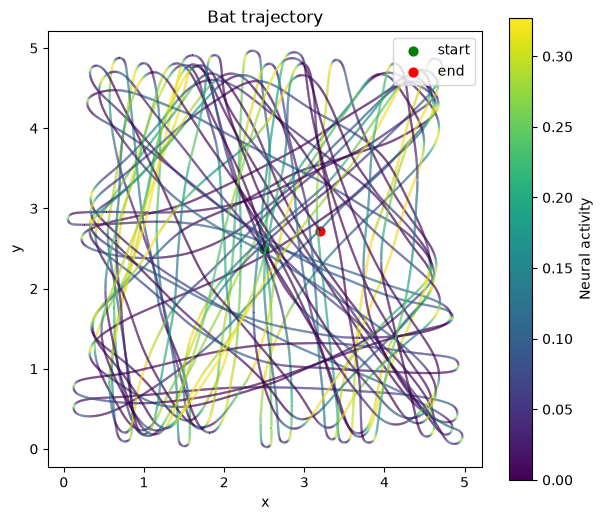

In [4]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

xy = bat_flight["pos"][:, :2]
activity = recording[:, 4]

segments = np.stack([xy[:-1], xy[1:]], axis=1)

norm = Normalize(vmin=activity.min(), vmax=activity.max())
lc = LineCollection(
    segments,
    cmap="viridis",
    norm=norm,
    linewidth=1.5,
)
lc.set_array(activity[:-1])

fig, ax = plt.subplots(figsize=(7, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(xy[0, 0], xy[0, 1], color="green", s=40, label="start")
ax.scatter(xy[-1, 0], xy[-1, 1], color="red", s=40, label="end")

ax.set_title("Bat trajectory")
ax.legend()

fig.colorbar(lc, ax=ax, label="Neural activity")
plt.show()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_2d_trajectory_activity.png"))

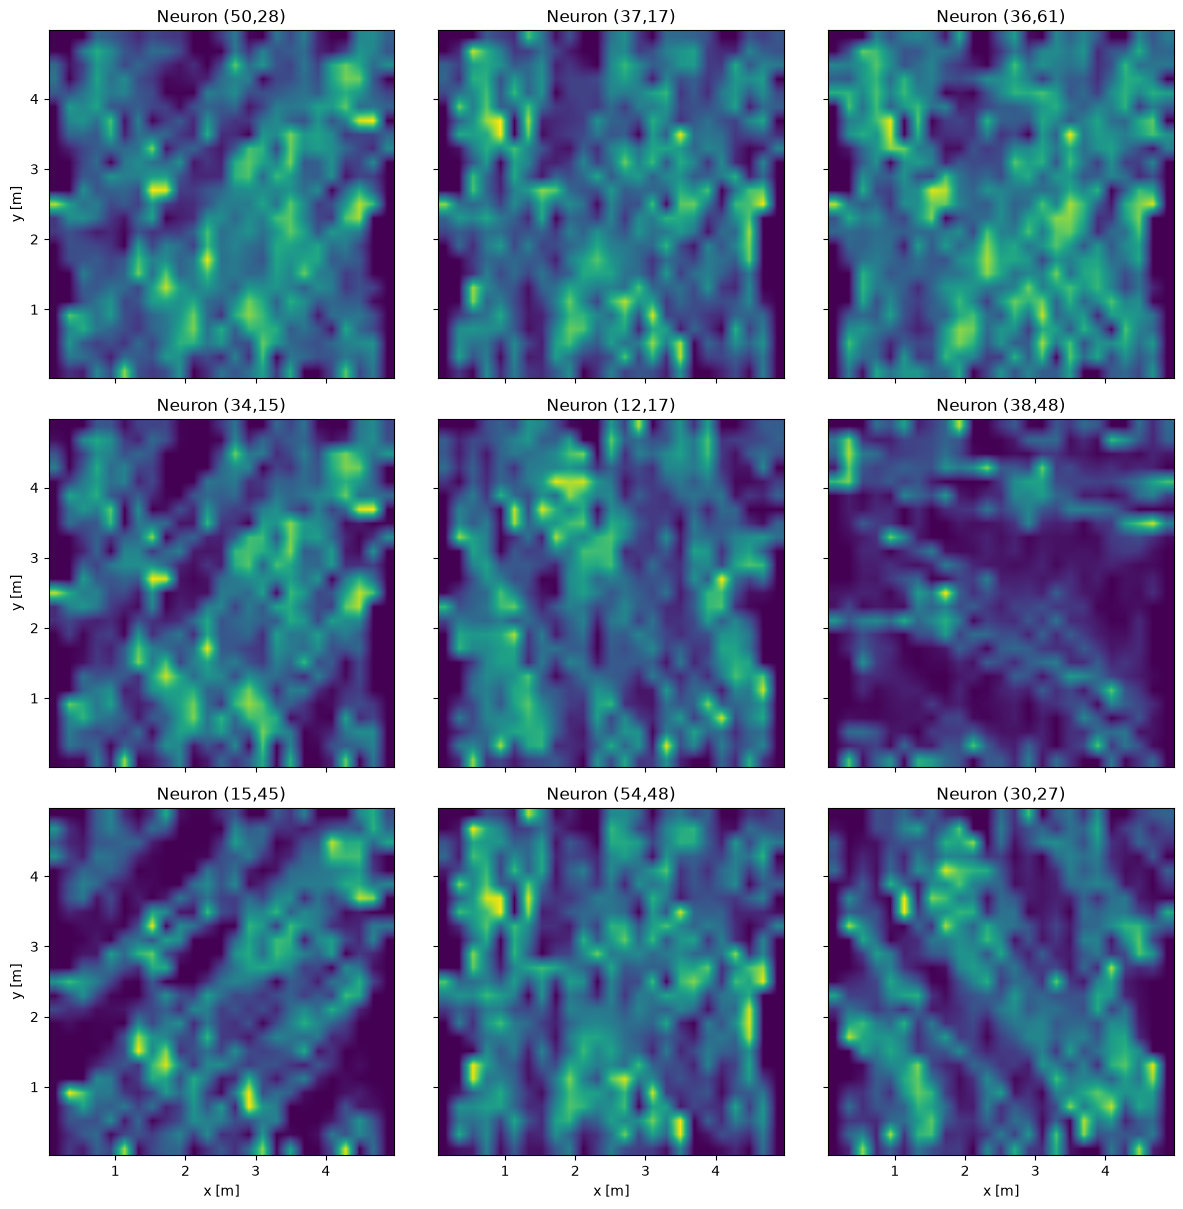

In [10]:
from grid_cells.plot_tools import activity_map, get_plot_grid

fig, axes = get_plot_grid(n_recorded_cells, sharex=True, sharey=True)
n_cols = axes.shape[0]

for neuron_index in range(n_recorded_cells):
    position_activity_map, _, edges = activity_map(
        bat_flight["pos"][:, [0, 1]], recording[:, neuron_index], nbins=25  # , sigma=2
    )
    axes[neuron_index // n_cols][neuron_index % n_cols].imshow(
        position_activity_map.T,
        extent=(edges[0][0], edges[0][-1], edges[-1][0], edges[0][-1]),
        interpolation="bilinear",
    )
    axes[neuron_index // n_cols][neuron_index % n_cols].set_title(
        f"Neuron ({recorded_cells[neuron_index][0]},{recorded_cells[neuron_index][1]})"
    )
fig.tight_layout()
for i in range(axes.shape[0]):
    axes[-1][i].set_xlabel("x [m]")
    axes[i][0].set_ylabel("y [m]")

fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_2d_position_activity.png"))

In [ ]:
import numpy as np

pos = bat_flight["pos"].astype(np.float32)
rate = recording[:, 0].astype(np.float64)

valid = rate > 0
pos = pos[valid]
rate = rate[valid]

p = rate / rate.sum()

rng = np.random.default_rng(42)

n_pairs = 100_000_000
chunk = 500_000

bins = 50
dist_hist = np.zeros(bins, dtype=np.int64)
weighted_hist = np.zeros(bins, dtype=np.float64)

pos_min = pos.min(axis=0)
pos_max = pos.max(axis=0)
max_dist = np.linalg.norm(pos_max - pos_min)

edges = np.linspace(0.5, max_dist, bins + 1)

for start in range(0, n_pairs, chunk):
    n = min(chunk, n_pairs - start)

    i = rng.choice(len(pos), size=n)
    j = rng.choice(len(pos), size=n)

    d = np.linalg.norm(pos[i] - pos[j], axis=1)

    dist_hist += np.histogram(d, bins=edges)[0]
    weighted_hist += np.histogram(d, bins=edges, weights=rate[i] * rate[j])[0]

# Normalize to a PDF
dist_pdf = dist_hist / (dist_hist.sum() * np.diff(edges))
weighted_dist_pdf = weighted_hist / (weighted_hist.sum() * np.diff(edges))
centers = (edges[:-1] + edges[1:]) / 2

Text(0, 0.5, 'Ratio')

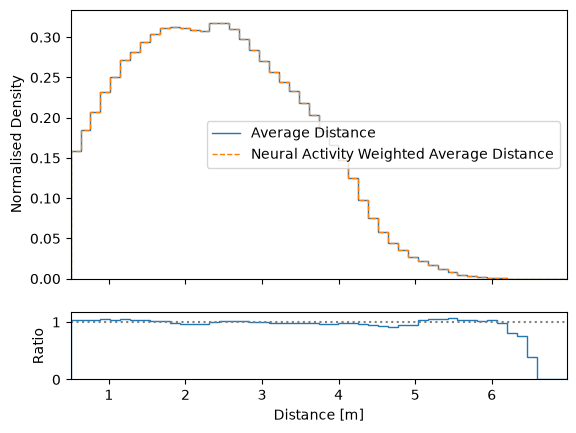

In [7]:
fig, ax = plt.subplots(nrows=2, height_ratios=(4, 1), sharex=True)
up, down = ax[0], ax[1]
up.stairs(weighted_dist_pdf, edges, label="Average Distance", linestyle="-")
up.stairs(
    weighted_dist_pdf,
    edges,
    label="Neural Activity Weighted Average Distance",
    linestyle="--",
)
up.set_ylabel("Normalised Density")
up.legend(loc="best")
ratio = weighted_dist_pdf / (dist_pdf + 1e-6)
down.set_xlabel("Distance [m]")
down.stairs(ratio, edges)
down.set_xlim(edges[0], edges[-1])
down.set_ylim(np.min(ratio) * 0.9, np.max(ratio) * 1.1)
down.axhline(y=1, color="grey", linestyle="dotted")
down.set_ylabel("Ratio")